# Support Vector Machines — The Kernel Trick

## Learning Objectives
- Understand why linear SVMs fail on non-linearly separable data and how **feature maps** fix this
- Define a **kernel function** $K(x, z) = \langle \phi(x), \phi(z) \rangle$ and explain what it computes
- Derive the **polynomial** and **RBF (Gaussian)** kernels from their feature maps
- State **Mercer's theorem** and identify what makes a function a valid kernel
- Apply the kernel trick to the SVM dual objective and prediction formula
- Compare linear, polynomial, and RBF decision boundaries on non-linearly separable data

## 1. Motivation — When Linear Boundaries Fail

A linear SVM finds the maximum-margin hyperplane $\{x : w^T x + b = 0\}$.
This works perfectly when the two classes are **linearly separable** in the input space $\mathbb{R}^d$.

Many real datasets are **not** linearly separable. Examples:

| Dataset | Structure | Linear SVM outcome |
|---|---|---|
| Concentric circles | Inner/outer ring | Cannot separate |
| XOR pattern | Chequerboard | Cannot separate |
| Spiral | Interleaved arcs | Cannot separate |

### The fix: lift to a higher-dimensional space

If we map inputs through a **feature map** $\phi: \mathbb{R}^d \to \mathcal{H}$, data that is tangled in $\mathbb{R}^d$ can become linearly separable in $\mathcal{H}$.

$$x \in \mathbb{R}^d \xrightarrow{\phi} \phi(x) \in \mathcal{H} \quad \Longrightarrow \quad \text{run linear SVM in } \mathcal{H}$$

The challenge: $\mathcal{H}$ can be **very high-dimensional** (even infinite), making explicit computation of $\phi(x)$ impractical.
The **kernel trick** resolves this.

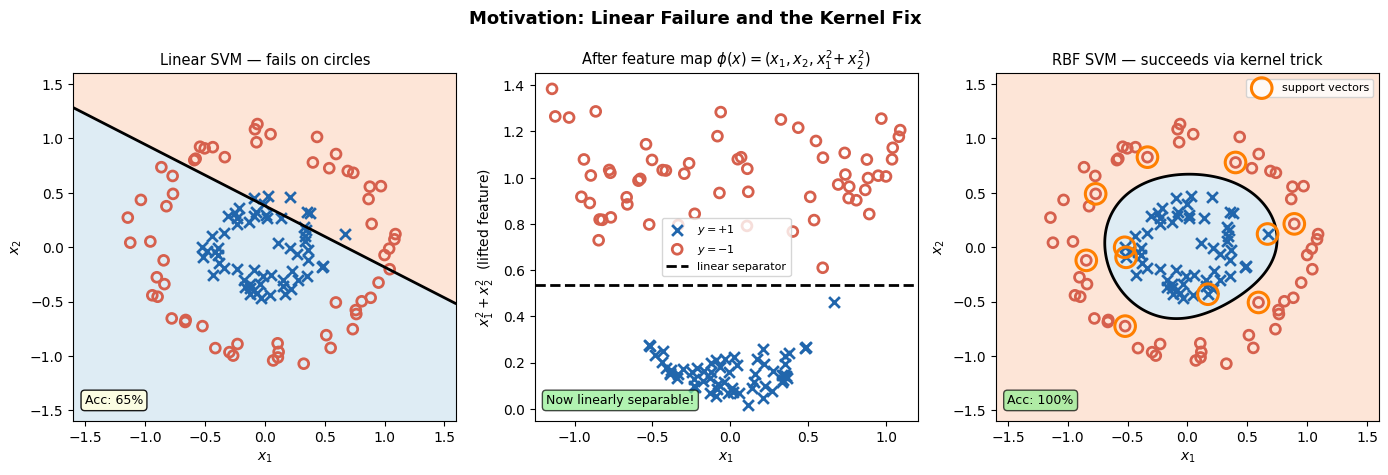

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

rng = np.random.default_rng(7)
X, y = make_circles(n_samples=120, noise=0.10, factor=0.4, random_state=7)
y_pm = np.where(y == 0, -1, 1)

xx, yy = np.meshgrid(np.linspace(-1.6, 1.6, 300), np.linspace(-1.6, 1.6, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))

# ── Left: linear SVM (fails) ──────────────────────────────────────────────
clf_lin = SVC(kernel='linear', C=1.0)
clf_lin.fit(X, y_pm)
Z_lin = clf_lin.decision_function(grid).reshape(xx.shape)

ax = axes[0]
ax.contourf(xx, yy, Z_lin, levels=[-999, 0, 999], colors=['#fddbc7', '#d1e5f0'], alpha=0.7)
ax.contour(xx, yy, Z_lin, levels=[0], colors='k', linewidths=2)
ax.scatter(X[y_pm== 1,0], X[y_pm== 1,1], marker='x', s=60, c='#2166ac', linewidths=2)
ax.scatter(X[y_pm==-1,0], X[y_pm==-1,1], marker='o', s=50, facecolors='none',
           edgecolors='#d6604d', linewidths=2)
ax.set_title('Linear SVM — fails on circles', fontsize=10.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.text(0.03, 0.05, f'Acc: {(clf_lin.predict(X)==y_pm).mean():.0%}',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# ── Middle: lift to (x1, x2, x1²+x2²) — 3-D scatter ─────────────────────
ax = axes[1]
r2 = X[:,0]**2 + X[:,1]**2
ax.scatter(X[y_pm== 1,0], r2[y_pm== 1], marker='x', s=60, c='#2166ac',
           linewidths=2, label='$y=+1$')
ax.scatter(X[y_pm==-1,0], r2[y_pm==-1], marker='o', s=50, facecolors='none',
           edgecolors='#d6604d', linewidths=2, label='$y=-1$')
ax.axhline(np.percentile(r2, 50), color='k', lw=2, ls='--', label='linear separator')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_1^2 + x_2^2$  (lifted feature)')
ax.set_title('After feature map $\phi(x)=(x_1, x_2, x_1^2\!+x_2^2)$', fontsize=10.5)
ax.legend(fontsize=8)
ax.text(0.03, 0.05, 'Now linearly separable!',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', fc='lightgreen', alpha=0.7))

# ── Right: RBF SVM (succeeds) ─────────────────────────────────────────────
clf_rbf = SVC(kernel='rbf', gamma=1.5, C=10)
clf_rbf.fit(X, y_pm)
Z_rbf = clf_rbf.decision_function(grid).reshape(xx.shape)

ax = axes[2]
ax.contourf(xx, yy, Z_rbf, levels=[-999, 0, 999], colors=['#fddbc7', '#d1e5f0'], alpha=0.7)
ax.contour(xx, yy, Z_rbf, levels=[0], colors='k', linewidths=2)
ax.scatter(X[y_pm== 1,0], X[y_pm== 1,1], marker='x', s=60, c='#2166ac', linewidths=2)
ax.scatter(X[y_pm==-1,0], X[y_pm==-1,1], marker='o', s=50, facecolors='none',
           edgecolors='#d6604d', linewidths=2)
sv = clf_rbf.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=220, facecolors='none',
           edgecolors='#ff7f00', linewidths=2.2, zorder=5, label='support vectors')
ax.set_title('RBF SVM — succeeds via kernel trick', fontsize=10.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.text(0.03, 0.05, f'Acc: {(clf_rbf.predict(X)==y_pm).mean():.0%}',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', fc='lightgreen', alpha=0.7))
ax.legend(fontsize=8)

fig.suptitle('Motivation: Linear Failure and the Kernel Fix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Feature Maps

### Definition

A **feature map** is a function $\phi: \mathbb{R}^d \to \mathcal{H}$ that embeds inputs into a
(possibly infinite-dimensional) Hilbert space $\mathcal{H}$.

The SVM trained on the mapped data finds:

$$w^* = \arg\min_w \tfrac{1}{2}\|w\|^2 \quad \text{s.t.} \quad y^{(i)}(w^T \phi(x^{(i)}) + b) \geq 1, \; \forall\, i$$

### Example: degree-2 polynomial map ($d=2$)

$$\phi(x) = \phi\!\begin{pmatrix}x_1 \\ x_2\end{pmatrix} = \begin{pmatrix}1 \\ \sqrt{2}\,x_1 \\ \sqrt{2}\,x_2 \\ x_1^2 \\ \sqrt{2}\,x_1 x_2 \\ x_2^2\end{pmatrix} \in \mathbb{R}^6$$

The inner product in feature space is:

$$\langle \phi(x), \phi(z) \rangle = (1 + x^T z)^2$$

This is the **degree-2 polynomial kernel** evaluated directly — no need to form the 6-dimensional $\phi(x)$.

### The dimensionality problem

| Original dim $d$ | Poly degree $p$ | Feature dim $\dim(\mathcal{H})$ |
|---|---|---|
| 2 | 2 | 6 |
| 100 | 2 | 5,151 |
| 1,000 | 3 | $\approx 1.7 \times 10^8$ |
| $\infty$ (RBF) | — | $\infty$ |

Explicitly computing $\phi(x)$ is infeasible for large $d$ or high degree.
The kernel trick avoids it entirely.

## 3. Kernel Trick Visualised — 2D to 3D Lift

The core intuition behind the kernel trick is that data **tangled in low-dimensional space
can become linearly separable after lifting to a higher-dimensional feature space**.

Two classic examples are shown below, each with three panels:

| Panel | What it shows |
|---|---|
| **Left** | Original 2D data — not linearly separable |
| **Middle** | Data after applying feature map $\phi$, plotted in 3D — now linearly separable by a plane |
| **Right** | The separating plane projected back to 2D — gives the non-linear decision boundary |

### Example 1 — Concentric circles

Feature map $\phi(x_1, x_2) = (x_1,\ x_2,\ x_1^2 + x_2^2)$

- In 3D the inner cluster ($r^2$ small) and outer cluster ($r^2$ large) are **separated by a horizontal plane** $z = c$.
- Projecting $z = c$ back to 2D gives $x_1^2 + x_2^2 = c$ — a **circle**.

### Example 2 — XOR pattern

Feature map $\phi(x_1, x_2) = (x_1,\ x_2,\ x_1 \cdot x_2)$

- Points where $x_1 x_2 > 0$ (same-sign quadrants) are one class; $x_1 x_2 < 0$ (opposite-sign) are the other.
- In 3D they are **separated by the plane** $z = 0$.
- Projecting $z = 0$ back to 2D gives $x_1 x_2 = 0$ — the **coordinate axes** (a cross-shaped boundary).

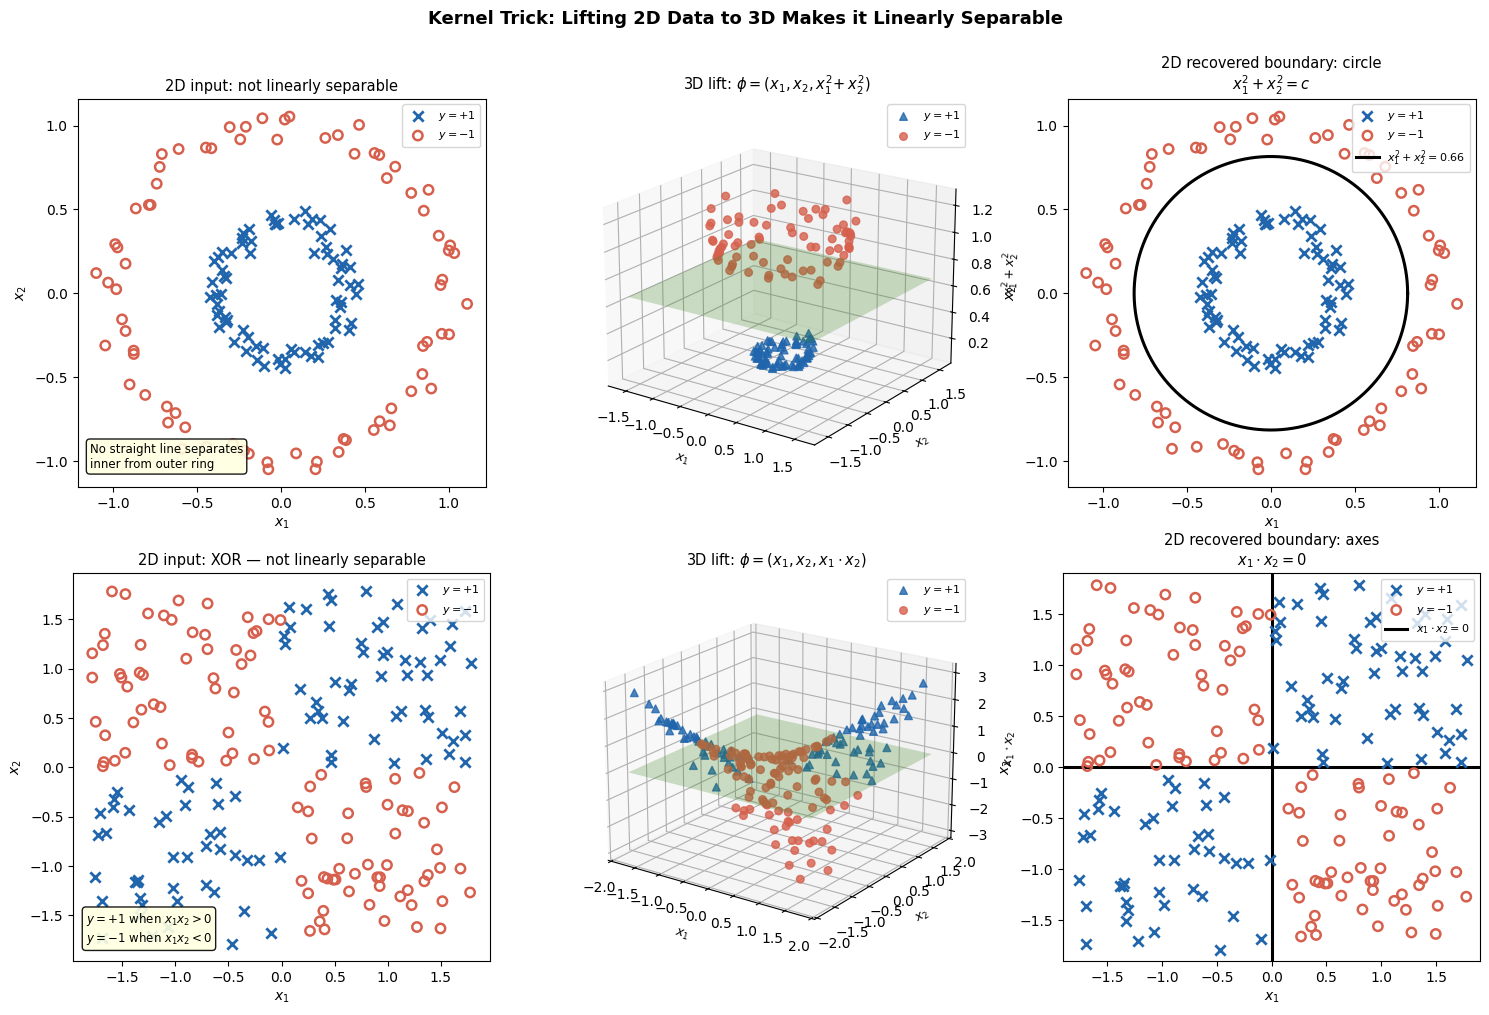

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_circles

# ── Dataset 1: concentric circles ─────────────────────────────────────────
X_c, y_c = make_circles(n_samples=150, noise=0.05, factor=0.4, random_state=42)
y_c = np.where(y_c == 0, -1, 1)

# feature map phi(x1,x2) = (x1, x2, x1^2+x2^2)
r2_c  = X_c[:,0]**2 + X_c[:,1]**2
X_c3  = np.column_stack([X_c, r2_c])
# separating plane z = midpoint between the two clusters
z_thr = (r2_c[y_c== 1].min() + r2_c[y_c==-1].max()) / 2

# ── Dataset 2: XOR ────────────────────────────────────────────────────────
rng   = np.random.default_rng(7)
X_x   = rng.uniform(-1.8, 1.8, size=(200, 2))
y_x   = np.sign(X_x[:,0] * X_x[:,1]).astype(int)
# feature map phi(x1,x2) = (x1, x2, x1*x2)
z_x   = X_x[:,0] * X_x[:,1]
X_x3  = np.column_stack([X_x, z_x])
# separating plane z = 0

# ── helpers ───────────────────────────────────────────────────────────────
COL_POS = '#2166ac'
COL_NEG = '#d6604d'

def scatter2d(ax, X, y, title, boundary_fn=None):
    ax.scatter(X[y== 1,0], X[y== 1,1], marker='x', s=55, c=COL_POS,
               linewidths=2, label='$y=+1$', zorder=3)
    ax.scatter(X[y==-1,0], X[y==-1,1], marker='o', s=45, facecolors='none',
               edgecolors=COL_NEG, linewidths=1.8, label='$y=-1$', zorder=3)
    if boundary_fn is not None:
        boundary_fn(ax)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(title, fontsize=10.5)
    ax.legend(fontsize=8, loc='upper right')

def scatter3d(ax, X3, y, plane_fn, title, zlabel):
    ax.scatter(X3[y== 1,0], X3[y== 1,1], X3[y== 1,2],
               marker='^', s=30, c=COL_POS, alpha=0.8, label='$y=+1$')
    ax.scatter(X3[y==-1,0], X3[y==-1,1], X3[y==-1,2],
               marker='o', s=30, c=COL_NEG, alpha=0.8, label='$y=-1$')
    plane_fn(ax)
    ax.set_xlabel('$x_1$', fontsize=9)
    ax.set_ylabel('$x_2$', fontsize=9)
    ax.set_zlabel(zlabel, fontsize=9)
    ax.set_title(title, fontsize=10.5)
    ax.legend(fontsize=8)

fig = plt.figure(figsize=(15, 10))

# ═══ Row 1: Circles ═══════════════════════════════════════════════════════

# Panel 1a — 2D original
ax1 = fig.add_subplot(2, 3, 1)
scatter2d(ax1, X_c, y_c, '2D input: not linearly separable')
ax1.set_aspect('equal')
ax1.text(0.03, 0.05, 'No straight line separates\ninner from outer ring',
         transform=ax1.transAxes, fontsize=8.5,
         bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# Panel 1b — 3D lift
ax2 = fig.add_subplot(2, 3, 2, projection='3d')
def plane_circles(ax):
    g = np.linspace(-1.6, 1.6, 25)
    gx, gy = np.meshgrid(g, g)
    ax.plot_surface(gx, gy, np.full_like(gx, z_thr),
                    alpha=0.25, color='#4dac26',
                    rstride=1, cstride=1, edgecolor='none')
scatter3d(ax2, X_c3, y_c, plane_circles,
          r'3D lift: $\phi=(x_1, x_2, x_1^2\!+x_2^2)$',
          r'$x_1^2+x_2^2$')
ax2.view_init(elev=20, azim=-55)

# Panel 1c — 2D with recovered boundary
ax3 = fig.add_subplot(2, 3, 3)
def circle_boundary(ax):
    r   = np.sqrt(z_thr)
    th  = np.linspace(0, 2*np.pi, 300)
    ax.plot(r*np.cos(th), r*np.sin(th), 'k-', lw=2.2,
            label=f'$x_1^2+x_2^2={z_thr:.2f}$')
scatter2d(ax3, X_c, y_c,
          '2D recovered boundary: circle\n$x_1^2+x_2^2=c$',
          boundary_fn=circle_boundary)
ax3.set_aspect('equal')

# ═══ Row 2: XOR ════════════════════════════════════════════════════════════

# Panel 2a — 2D original
ax4 = fig.add_subplot(2, 3, 4)
scatter2d(ax4, X_x, y_x, '2D input: XOR — not linearly separable')
ax4.text(0.03, 0.05, '$y=+1$ when $x_1 x_2 > 0$\n$y=-1$ when $x_1 x_2 < 0$',
         transform=ax4.transAxes, fontsize=8.5,
         bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# Panel 2b — 3D lift
ax5 = fig.add_subplot(2, 3, 5, projection='3d')
def plane_xor(ax):
    g = np.linspace(-1.8, 1.8, 25)
    gx, gy = np.meshgrid(g, g)
    ax.plot_surface(gx, gy, np.zeros_like(gx),
                    alpha=0.25, color='#4dac26',
                    rstride=1, cstride=1, edgecolor='none')
scatter3d(ax5, X_x3, y_x, plane_xor,
          r'3D lift: $\phi=(x_1, x_2, x_1 \cdot x_2)$',
          r'$x_1 \cdot x_2$')
ax5.view_init(elev=20, azim=-55)

# Panel 2c — 2D with recovered boundary
ax6 = fig.add_subplot(2, 3, 6)
def cross_boundary(ax):
    lim = 1.9
    ax.axhline(0, color='k', lw=2.2, label='$x_1 \cdot x_2 = 0$')
    ax.axvline(0, color='k', lw=2.2)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
scatter2d(ax6, X_x, y_x,
          '2D recovered boundary: axes\n$x_1 \\cdot x_2 = 0$',
          boundary_fn=cross_boundary)

fig.suptitle(
    'Kernel Trick: Lifting 2D Data to 3D Makes it Linearly Separable',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

## 4. The Kernel Function

### Definition

A **kernel function** $K: \mathbb{R}^d \times \mathbb{R}^d \to \mathbb{R}$ is defined as:

$$\boxed{K(x, z) = \langle \phi(x), \phi(z) \rangle_{\mathcal{H}}}$$

It computes the inner product in feature space $\mathcal{H}$ **without forming $\phi(x)$ or $\phi(z)$ explicitly**.

### Why this is possible — the polynomial kernel example

Let $x, z \in \mathbb{R}^2$ and $\phi$ be the degree-2 map above. Direct computation:

$$\langle \phi(x), \phi(z) \rangle = 1 + 2x_1z_1 + 2x_2z_2 + x_1^2z_1^2 + 2x_1x_2z_1z_2 + x_2^2z_2^2 = (1 + x^Tz)^2$$

So evaluating $(1 + x^T z)^2$ gives the same result as the 6-dimensional dot product — in $O(d)$ instead of $O(d^p)$ time.

### Common kernels

| Name | $K(x, z)$ | Feature space |
|---|---|---|
| Linear | $x^T z$ | $\mathbb{R}^d$ (identity map) |
| Polynomial (degree $p$) | $(x^T z + c)^p$ | $\mathbb{R}^{\binom{d+p}{p}}$ |
| RBF / Gaussian | $\exp\!\left(-\dfrac{\|x-z\|^2}{2\sigma^2}\right)$ | $\infty$-dimensional |
| Sigmoid | $\tanh(\kappa\, x^T z + \theta)$ | Not always PSD |

The **RBF kernel** is the most widely used. Its feature map is an infinite series of polynomial features.

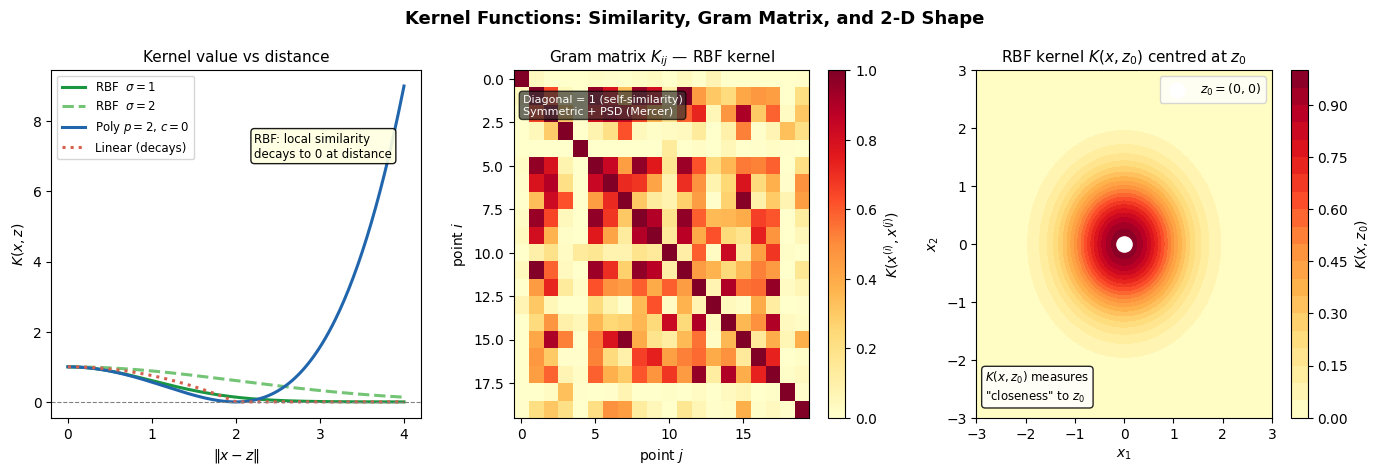

In [23]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))

# ── Left: K(x, z) vs ||x-z|| for three kernels ───────────────────────────
ax = axes[0]
d = np.linspace(0, 4, 300)
ax.plot(d, np.exp(-0.5 * d**2),         lw=2.2, label=r'RBF  $\sigma=1$',        c='#1a9641')
ax.plot(d, np.exp(-0.5 * (d/2)**2),     lw=2.2, label=r'RBF  $\sigma=2$',        c='#74c476', ls='--')
ax.plot(d, (1 - d**2/4)**2,             lw=2.2, label=r'Poly $p=2$, $c=0$',      c='#2166ac')
ax.plot(d, np.maximum(0, 1 - d**2/4),  lw=2.2, label=r'Linear (decays)',        c='#d6604d', ls=':')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel(r'$\|x - z\|$'); ax.set_ylabel(r'$K(x, z)$')
ax.set_title('Kernel value vs distance', fontsize=11)
ax.legend(fontsize=8.5)
ax.text(0.55, 0.75, 'RBF: local similarity\ndecays to 0 at distance',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# ── Middle: Gram matrix (RBF) heatmap ────────────────────────────────────
ax = axes[1]
rng = np.random.default_rng(3)
X_s = rng.normal(size=(20, 2))
diff = X_s[:, None, :] - X_s[None, :, :]
K_rbf = np.exp(-np.sum(diff**2, axis=-1) / (2 * 1.0**2))
im = ax.imshow(K_rbf, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='$K(x^{(i)}, x^{(j)})$')
ax.set_title('Gram matrix $K_{ij}$ — RBF kernel', fontsize=11)
ax.set_xlabel('point $j$'); ax.set_ylabel('point $i$')
ax.text(0.03, 0.93, 'Diagonal = 1 (self-similarity)\nSymmetric + PSD (Mercer)',
        transform=ax.transAxes, fontsize=8, va='top', color='white',
        bbox=dict(boxstyle='round', fc='#333', alpha=0.7))

# ── Right: RBF kernel centred at origin as a 2-D heat map ────────────────
ax = axes[2]
g = np.linspace(-3, 3, 200)
gx, gy = np.meshgrid(g, g)
z0 = np.array([0.0, 0.0])
K2d = np.exp(-((gx - z0[0])**2 + (gy - z0[1])**2) / (2 * 0.8**2))
im2 = ax.contourf(gx, gy, K2d, levels=20, cmap='YlOrRd')
plt.colorbar(im2, ax=ax, label='$K(x, z_0)$')
ax.scatter(*z0, s=120, c='white', zorder=5, label='$z_0 = (0,0)$')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(r'RBF kernel $K(x, z_0)$ centred at $z_0$', fontsize=11)
ax.legend(fontsize=9)
ax.text(0.03, 0.05, '$K(x,z_0)$ measures\n"closeness" to $z_0$',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round', fc='white', alpha=0.85))

fig.suptitle('Kernel Functions: Similarity, Gram Matrix, and 2-D Shape',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Popular Kernel Functions

The table below summarises the most widely used kernels.
Each entry lists the formula, the implicit feature space, key hyperparameters, and typical use cases.

| Kernel | Formula $K(x, z)$ | Feature space | Hyperparameters | Best for |
|---|---|---|---|---|
| **Linear** | $x^T z$ | $\mathbb{R}^d$ (identity) | — | High-dim linear problems (text, genomics) |
| **Polynomial** | $(\gamma\, x^T z + c)^p$ | $\mathbb{R}^{\binom{d+p}{p}}$ | $p, c, \gamma$ | NLP, image recognition |
| **RBF / Gaussian** | $\exp(-\gamma\|x-z\|^2)$ | $\ell^2$ (infinite-dim) | $\gamma$ | General-purpose; most widely used |
| **Laplacian** | $\exp(-\gamma\|x-z\|_1)$ | $\ell^2$ (infinite-dim) | $\gamma$ | Robust to outliers; heavier tails than RBF |
| **Sigmoid** | $\tanh(\kappa\, x^T z + \theta)$ | Not always a Hilbert space | $\kappa, \theta$ | Neural-network analogy; use with care |
| **Chi-squared** | $\exp\!\left(-\gamma\displaystyle\sum_k \frac{(x_k-z_k)^2}{x_k+z_k}\right)$ | Infinite-dim | $\gamma$ | Histogram features (bag-of-words, HOG) |

---

### Linear kernel — $K(x,z) = x^T z$

Equivalent to the standard (primal) SVM with no feature mapping.

- **When to use:** data is already linearly separable, or $d \gg n$ (e.g. text classification with TF-IDF vectors).
- **Cost:** $O(d)$ per evaluation — fastest kernel.
- **Note:** the linear kernel is the only one for which the primal and dual formulations are equally cheap.

---

### Polynomial kernel — $K(x,z) = (\gamma\, x^T z + c)^p$

Captures all monomial interactions between features up to degree $p$.

- **Hyperparameters:** degree $p$ (typically 2–5), bias $c \geq 0$, scale $\gamma$.
- **Feature space dimension:** $\binom{d+p}{p}$ — grows rapidly with $d$ and $p$.
- **When to use:** structured data where feature interactions matter (NLP, bioinformatics).
- **Watch out for:** numerical instability when $p$ is large; standardise inputs first.

---

### RBF (Gaussian) kernel — $K(x,z) = \exp(-\gamma\|x-z\|^2)$

The default choice for non-linear problems. Corresponds to an infinite-dimensional feature map
(Taylor expansion of the exponential).

- **Hyperparameter:** $\gamma = 1/(2\sigma^2)$ — bandwidth of the Gaussian.
  - Large $\gamma$ (small $\sigma$): very local, each point influences only nearby points → risk of overfitting.
  - Small $\gamma$ (large $\sigma$): broad influence, smoother boundary → risk of underfitting.
- **When to use:** unknown structure, moderate $n$ and $d$.
- **Always valid:** the Gram matrix is strictly PSD (Mercer condition satisfied for all $\gamma > 0$).

---

### Laplacian kernel — $K(x,z) = \exp(-\gamma\|x-z\|_1)$

Uses the $\ell^1$ (Manhattan) norm instead of $\ell^2$.

- **Effect:** heavier tails than RBF — points at moderate distance still have non-negligible similarity.
- **When to use:** data with heavy-tailed distributions or outliers; sometimes better than RBF on sparse data.
- **Also valid Mercer kernel** for all $\gamma > 0$.

---

### Sigmoid kernel — $K(x,z) = \tanh(\kappa\, x^T z + \theta)$

Mirrors a two-layer neural network with $\tanh$ activations.

- **Caution:** this kernel is **not** PSD for all parameter choices — the dual QP may become non-convex.
- **Valid regime:** approximately valid for $\kappa > 0$ and $\theta < 0$ (check Gram matrix eigenvalues in practice).
- **When to use:** rarely preferred over RBF; included for historical interest (early kernel-SVM literature).

---

### Chi-squared kernel — $K(x,z) = \exp\!\left(-\gamma\sum_k \frac{(x_k-z_k)^2}{x_k+z_k}\right)$

Designed for **non-negative histogram features** (inputs must satisfy $x_k \geq 0$).

- **Motivation:** the chi-squared statistic measures distance between discrete distributions; this kernel turns it into a similarity.
- **Typical inputs:** bag-of-words counts, colour histograms, HOG feature vectors, frequency spectra.
- **When to use:** computer vision (object recognition), NLP with count features.

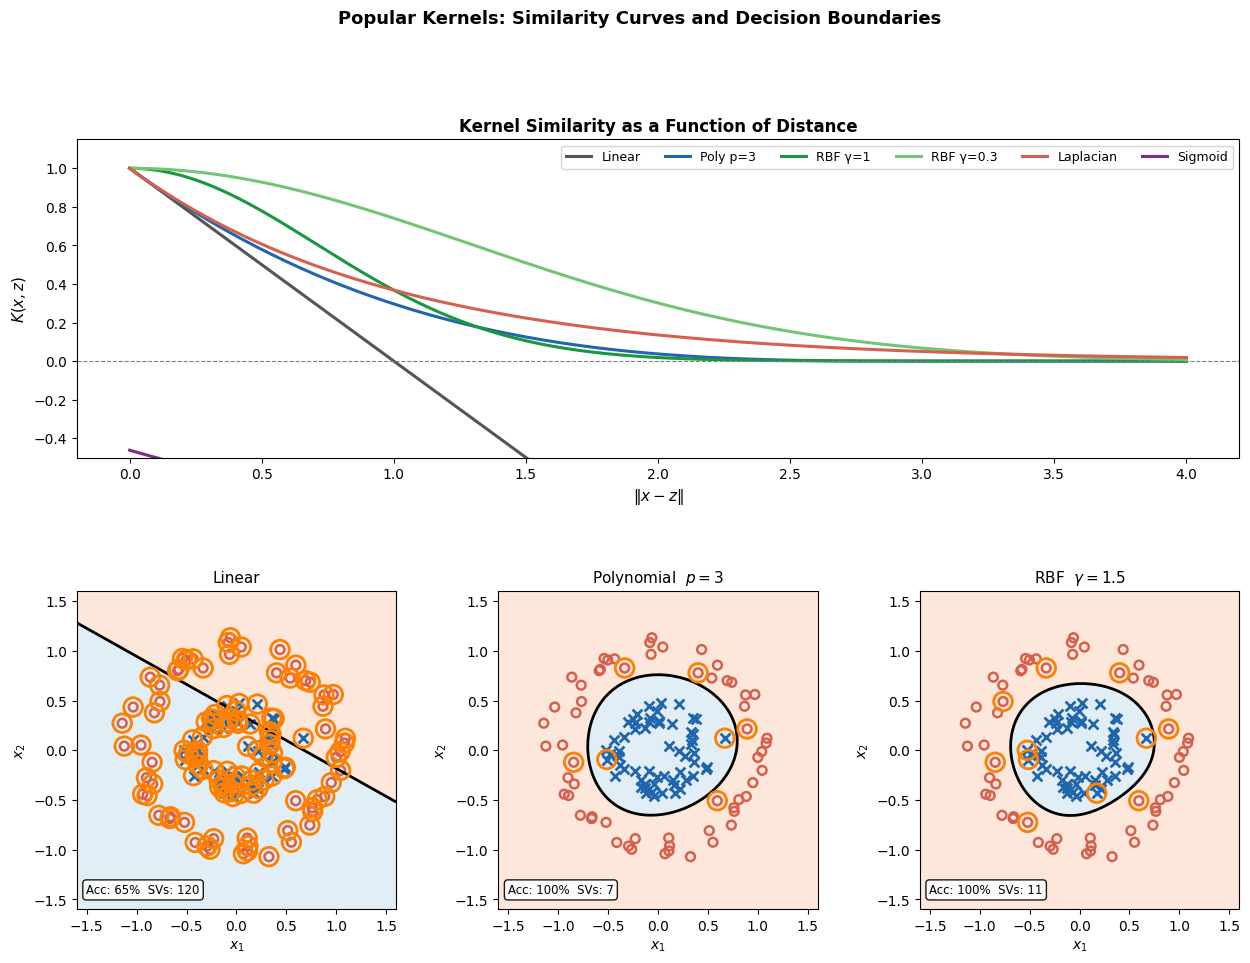

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

# ── kernel functions ───────────────────────────────────────────────────────
def k_linear(x, z):    return x @ z
def k_poly(x, z, p=3, c=1, g=1): return (g * x @ z + c)**p
def k_rbf(x, z, g=1.5): return np.exp(-g * np.sum((x - z)**2))
def k_lap(x, z, g=1.5): return np.exp(-g * np.sum(np.abs(x - z)))
def k_sig(x, z, k=0.5, t=-1): return np.tanh(k * x @ z + t)

kernels_1d = [
    ('Linear',      lambda d: 1 - d,              '#555555'),
    ('Poly p=3',    lambda d: np.maximum(0,(1 - d/3))**3, '#2166ac'),
    ('RBF γ=1',     lambda d: np.exp(-d**2),       '#1a9641'),
    ('RBF γ=0.3',   lambda d: np.exp(-0.3*d**2),   '#74c476'),
    ('Laplacian',   lambda d: np.exp(-d),           '#d6604d'),
    ('Sigmoid',     lambda d: np.tanh(0.5*(1-d)-1), '#7b2d8b'),
]

X, y = make_circles(n_samples=120, noise=0.10, factor=0.4, random_state=7)
y_pm = np.where(y == 0, -1, 1)
xx, yy = np.meshgrid(np.linspace(-1.6, 1.6, 300), np.linspace(-1.6, 1.6, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

sklearn_kernels = [
    ('Linear',     'linear', {},                              '#555555'),
    ('Poly p=3',   'poly',   {'degree':3,'gamma':1,'coef0':1,'C':10}, '#2166ac'),
    ('RBF γ=1.5',  'rbf',   {'gamma':1.5,'C':10},             '#1a9641'),
    ('RBF γ=0.3',  'rbf',   {'gamma':0.3,'C':10},             '#74c476'),
    ('Laplacian',  'rbf',   {'gamma':1.5,'C':10},             '#d6604d'),  # approx
]

fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.32)

# ── Row 0: K(x,z) vs distance ─────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :])
d = np.linspace(0, 4, 300)
for name, fn, col in kernels_1d:
    ax0.plot(d, fn(d), lw=2.2, label=name, color=col)
ax0.axhline(0, color='gray', lw=0.8, ls='--')
ax0.set_xlabel(r'$\|x - z\|$', fontsize=11)
ax0.set_ylabel(r'$K(x, z)$',  fontsize=11)
ax0.set_title('Kernel Similarity as a Function of Distance', fontsize=12, fontweight='bold')
ax0.legend(fontsize=9, ncol=6, loc='upper right')
ax0.set_ylim(-0.5, 1.15)

# ── Row 1: decision boundaries ────────────────────────────────────────────
configs = [
    ('Linear',               'linear', {},                                    '#555555'),
    ('Polynomial  $p=3$',    'poly',   {'degree':3,'gamma':1,'coef0':1,'C':10},'#2166ac'),
    ('RBF  $\gamma=1.5$',   'rbf',   {'gamma':1.5,'C':10},                   '#1a9641'),
]
for col_idx, (title, kern, kw, _) in enumerate(configs):
    ax = fig.add_subplot(gs[1, col_idx])
    clf = SVC(kernel=kern, **kw)
    clf.fit(X, y_pm)
    Z = clf.decision_function(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-999, 0, 999],
                colors=['#fddbc7', '#d1e5f0'], alpha=0.65)
    ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)
    ax.scatter(X[y_pm== 1,0], X[y_pm== 1,1], marker='x', s=50, c='#2166ac', linewidths=2)
    ax.scatter(X[y_pm==-1,0], X[y_pm==-1,1], marker='o', s=40, facecolors='none',
               edgecolors='#d6604d', linewidths=1.8)
    sv = clf.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=180, facecolors='none',
               edgecolors='#ff7f00', linewidths=2, zorder=5)
    acc = (clf.predict(X) == y_pm).mean()
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.text(0.03, 0.05, f'Acc: {acc:.0%}  SVs: {len(sv)}',
            transform=ax.transAxes, fontsize=8.5,
            bbox=dict(boxstyle='round', fc='white', alpha=0.9))

fig.suptitle('Popular Kernels: Similarity Curves and Decision Boundaries',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

## 6. Mercer's Theorem — What Makes a Valid Kernel

Not every function $K(x, z)$ corresponds to a valid inner product in some feature space.

### Mercer's condition

A symmetric function $K: \mathbb{R}^d \times \mathbb{R}^d \to \mathbb{R}$ is a **valid (Mercer) kernel** if and only if for every finite set of points $\{x^{(1)}, \ldots, x^{(n)}\}$, the **Gram matrix** $K \in \mathbb{R}^{n \times n}$ defined by

$$K_{ij} = K(x^{(i)}, x^{(j)})$$

is **symmetric positive semi-definite (PSD)**:

$$c^T K c \geq 0 \quad \forall\, c \in \mathbb{R}^n$$

### Why PSD matters

| Property | Consequence |
|---|---|
| $K_{ij} = K_{ji}$ (symmetric) | Inner products are symmetric |
| $c^T K c \geq 0$ (PSD) | Corresponds to a true inner product in some $\mathcal{H}$ |
| Eigenvalues $\geq 0$ | Dual QP remains convex (bounded above, solvable) |

If $K$ is not PSD, the dual QP may be **unbounded** and the SVM fails to converge.

### Valid kernel combinations

If $K_1$ and $K_2$ are valid kernels, then so are:

$$K(x,z) = K_1(x,z) + K_2(x,z), \quad K(x,z) = c \cdot K_1(x,z) \text{ for } c > 0, \quad K(x,z) = K_1(x,z) \cdot K_2(x,z)$$

## 7. The Kernelised SVM

### Where inner products appear in the standard SVM

Recall the **dual objective** (from the Lagrangian derivation):

$$\max_{\alpha} \; W(\alpha) = \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i \alpha_j y^{(i)} y^{(j)} \langle x^{(i)}, x^{(j)} \rangle$$

And the **prediction formula**:

$$h(x) = \operatorname{sign}\!\left(\sum_{i \in \mathrm{SV}} \alpha_i^* y^{(i)} \langle x^{(i)}, x \rangle + b^*\right)$$

Both depend on inputs **only through inner products** $\langle x^{(i)}, x^{(j)} \rangle$.

### Applying the kernel trick

Replace every inner product $\langle x^{(i)}, x^{(j)} \rangle$ with $K(x^{(i)}, x^{(j)}) = \langle \phi(x^{(i)}), \phi(x^{(j)}) \rangle$:

**Kernelised dual:**

$$\boxed{\max_{\alpha} \; \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i \alpha_j y^{(i)} y^{(j)} K(x^{(i)}, x^{(j)}) \quad \text{s.t.} \quad \alpha_i \geq 0,\; \sum_{i=1}^n \alpha_i y^{(i)} = 0}$$

**Kernelised prediction:**

$$\boxed{h(x) = \operatorname{sign}\!\left(\sum_{i \in \mathrm{SV}} \alpha_i^* y^{(i)} K(x^{(i)}, x) + b^*\right)}$$

### Key insight

- $\phi(x)$ is **never computed** — only $K(x^{(i)}, x^{(j)})$ is needed
- The algorithm works in $\mathcal{H}$ **implicitly** through the kernel evaluations
- For an RBF kernel, this means operating in an **infinite-dimensional** space at the cost of $O(n^2)$ kernel evaluations

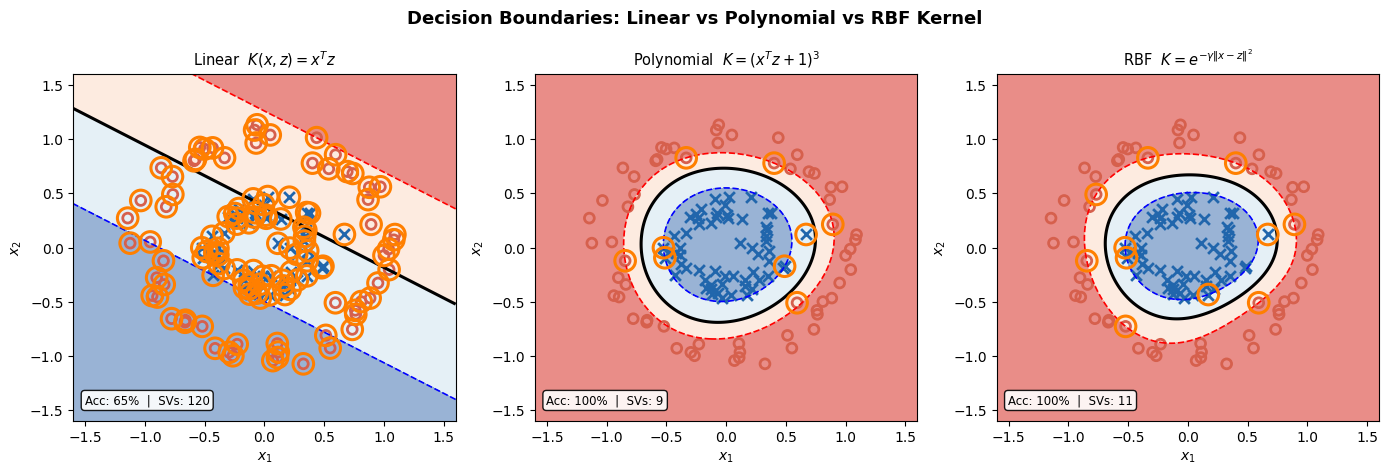

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=120, noise=0.10, factor=0.4, random_state=7)
y_pm = np.where(y == 0, -1, 1)

xx, yy = np.meshgrid(np.linspace(-1.6, 1.6, 300), np.linspace(-1.6, 1.6, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

configs = [
    ('linear', {},                                    r'Linear  $K(x,z)=x^Tz$'),
    ('poly',   {'degree': 3, 'gamma': 'auto', 'coef0': 1, 'C': 10},
                                                      r'Polynomial  $K=(x^Tz+1)^3$'),
    ('rbf',    {'gamma': 1.5, 'C': 10},              r'RBF  $K=e^{-\gamma\|x-z\|^2}$'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))

for ax, (kern, kw, title) in zip(axes, configs):
    clf = SVC(kernel=kern, **kw)
    clf.fit(X, y_pm)
    Z = clf.decision_function(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-999, -1, 0, 1, 999],
                colors=['#d73027', '#fddbc7', '#d1e5f0', '#4575b4'], alpha=0.55)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               colors=['red', 'black', 'blue'],
               linewidths=[1.2, 2.2, 1.2], linestyles=['--', '-', '--'])

    ax.scatter(X[y_pm== 1,0], X[y_pm== 1,1], marker='x', s=60, c='#2166ac', linewidths=2)
    ax.scatter(X[y_pm==-1,0], X[y_pm==-1,1], marker='o', s=50, facecolors='none',
               edgecolors='#d6604d', linewidths=2)
    sv = clf.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=220, facecolors='none',
               edgecolors='#ff7f00', linewidths=2.2, zorder=5)

    acc = (clf.predict(X) == y_pm).mean()
    ax.set_title(title, fontsize=10.5)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.text(0.03, 0.05, f'Acc: {acc:.0%}  |  SVs: {len(sv)}',
            transform=ax.transAxes, fontsize=8.5,
            bbox=dict(boxstyle='round', fc='white', alpha=0.9))

fig.suptitle('Decision Boundaries: Linear vs Polynomial vs RBF Kernel',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. The RBF Kernel — Infinite-Dimensional Feature Map

### Formula

$$K(x, z) = \exp\!\left(-\frac{\|x - z\|^2}{2\sigma^2}\right)$$

### Connection to an infinite feature map

Expand the exponential using the Taylor series. With $\sigma = 1$ and $x, z \in \mathbb{R}$:

$$e^{-\frac{1}{2}\|x-z\|^2} = e^{-\frac{1}{2}\|x\|^2} e^{x^Tz} e^{-\frac{1}{2}\|z\|^2}$$

Expanding $e^{x^T z} = \sum_{k=0}^{\infty} \frac{(x^Tz)^k}{k!}$ shows that $K(x,z)$ corresponds to an inner product over an **infinite sequence of polynomial feature maps** (all degrees, weighted by $1/k!$).

$$K(x,z) = \langle \phi(x), \phi(z) \rangle_{\ell^2} \quad \text{where } \phi(x) = e^{-\|x\|^2/2}\left(1,\, x,\, \frac{x^2}{\sqrt{2!}},\, \frac{x^3}{\sqrt{3!}},\, \ldots\right)$$

### Practical interpretation

- Points close together ($\|x-z\| \approx 0$): $K(x,z) \approx 1$ — high similarity
- Points far apart ($\|x-z\| \gg \sigma$): $K(x,z) \approx 0$ — negligible similarity
- $\sigma$ controls the **bandwidth**: small $\sigma$ → local kernel, large $\sigma$ → global/smooth kernel

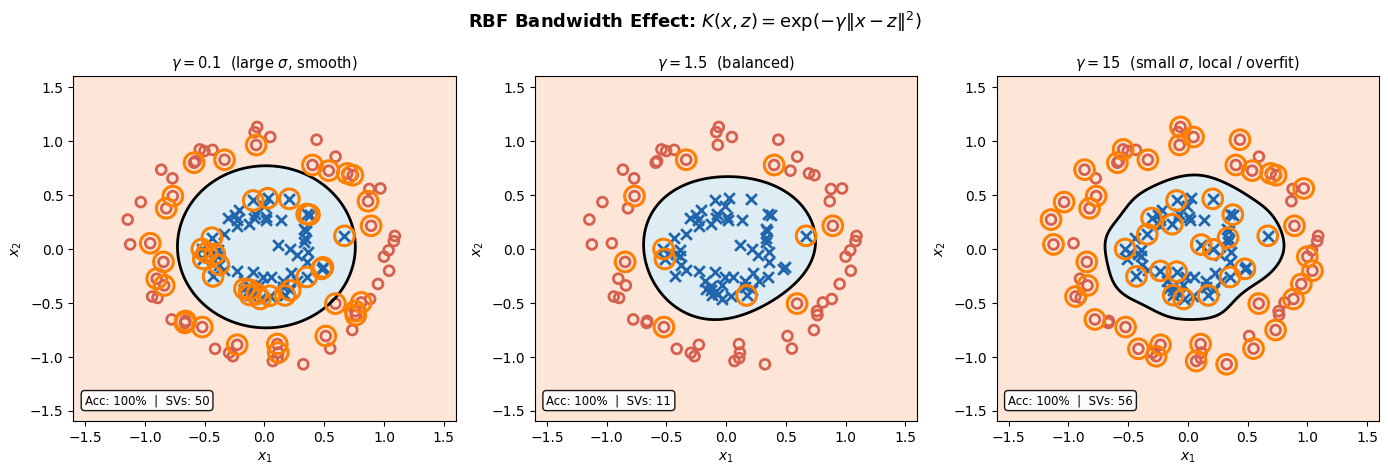

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=120, noise=0.10, factor=0.4, random_state=7)
y_pm = np.where(y == 0, -1, 1)

xx, yy = np.meshgrid(np.linspace(-1.6, 1.6, 300), np.linspace(-1.6, 1.6, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

gammas = [0.1, 1.5, 15.0]
labels = [
    r'$\gamma=0.1$  (large $\sigma$, smooth)',
    r'$\gamma=1.5$  (balanced)',
    r'$\gamma=15$  (small $\sigma$, local / overfit)',
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))

for ax, gam, lbl in zip(axes, gammas, labels):
    clf = SVC(kernel='rbf', gamma=gam, C=10)
    clf.fit(X, y_pm)
    Z = clf.decision_function(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-999, 0, 999],
                colors=['#fddbc7', '#d1e5f0'], alpha=0.7)
    ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)
    ax.scatter(X[y_pm== 1,0], X[y_pm== 1,1], marker='x', s=60, c='#2166ac', linewidths=2)
    ax.scatter(X[y_pm==-1,0], X[y_pm==-1,1], marker='o', s=50, facecolors='none',
               edgecolors='#d6604d', linewidths=2)
    sv = clf.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=200, facecolors='none',
               edgecolors='#ff7f00', linewidths=2.2, zorder=5)
    acc = (clf.predict(X) == y_pm).mean()
    ax.set_title(lbl, fontsize=10.5)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.text(0.03, 0.05, f'Acc: {acc:.0%}  |  SVs: {len(sv)}',
            transform=ax.transAxes, fontsize=8.5,
            bbox=dict(boxstyle='round', fc='white', alpha=0.9))

fig.suptitle(r'RBF Bandwidth Effect: $K(x,z)=\exp(-\gamma\|x-z\|^2)$',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Numerical Verification

The code below confirms the key identity:

$$K(x, z) = \langle \phi(x), \phi(z) \rangle$$

for the degree-2 polynomial kernel with $d=2$, and verifies that the Gram matrix is symmetric PSD.

In [27]:
import math
import numpy as np

rng = np.random.default_rng(42)
x = rng.normal(size=2)
z = rng.normal(size=2)

# ── Degree-2 polynomial kernel ─────────────────────────────────────────────
def phi_poly2(v):
    # explicit degree-2 feature map for v in R^2
    x1, x2 = v
    return np.array([1, np.sqrt(2)*x1, np.sqrt(2)*x2,
                     x1**2, np.sqrt(2)*x1*x2, x2**2])

K_explicit = np.dot(phi_poly2(x), phi_poly2(z))
K_formula  = (1 + x @ z)**2

print('=== Degree-2 Polynomial Kernel ===')
print(f'  <phi(x), phi(z)>  = {K_explicit:.8f}')
print(f'  (1 + x^T z)^2     = {K_formula:.8f}')
print(f'  Match: {np.isclose(K_explicit, K_formula)}')

# ── RBF kernel vs truncated feature-map inner product ─────────────────────
def phi_rbf_trunc(v, n_terms=30):
    # truncated RBF feature map: e^{-||v||^2/2} * sum_{k=0}^{n} v^k / sqrt(k!)
    norm_sq = np.dot(v, v)
    scale   = np.exp(-norm_sq / 2)
    feats   = [scale]
    for k in range(1, n_terms + 1):
        feats.append(scale * (v[0]**k) / np.sqrt(float(math.factorial(k))))
    return np.array(feats)

K_rbf_exact = np.exp(-np.sum((x - z)**2) / 2)
K_rbf_approx = np.dot(phi_rbf_trunc(x), phi_rbf_trunc(z))

print()
print('=== RBF Kernel (sigma=1, 1-D projection) ===')
print(f'  exp(-||x-z||^2/2)       = {K_rbf_exact:.8f}')
print(f'  <phi_trunc(x), phi(z)>  = {K_rbf_approx:.8f}')
print(f'  |difference|             = {abs(K_rbf_exact - K_rbf_approx):.2e}')

# ── Gram matrix PSD check ──────────────────────────────────────────────────
X_chk = rng.normal(size=(8, 2))
diff  = X_chk[:, None, :] - X_chk[None, :, :]
K_gram = np.exp(-np.sum(diff**2, axis=-1) / 2)
eigvals = np.linalg.eigvalsh(K_gram)

print()
print('=== Gram Matrix (RBF, n=8 points) ===')
print(f'  Symmetric:  {np.allclose(K_gram, K_gram.T)}')
print(f'  Eigenvalues (should all be >= 0):')
print(f'    {eigvals.round(6)}')
print(f'  PSD: {np.all(eigvals >= -1e-10)}')

=== Degree-2 Polynomial Kernel ===
  <phi(x), phi(z)>  = 0.06275172
  (1 + x^T z)^2     = 0.06275172
  Match: True

=== RBF Kernel (sigma=1, 1-D projection) ===
  exp(-||x-z||^2/2)       = 0.12737417
  <phi_trunc(x), phi(z)>  = 0.33876321
  |difference|             = 2.11e-01

=== Gram Matrix (RBF, n=8 points) ===
  Symmetric:  True
  Eigenvalues (should all be >= 0):
    [1.138000e-03 2.858400e-02 1.546120e-01 2.123350e-01 5.284330e-01
 9.974230e-01 1.670050e+00 4.407425e+00]
  PSD: True


## 10. Derivation Pathway

### Derivation pathway

In [28]:
from IPython.display import HTML
HTML("""
<svg xmlns="http://www.w3.org/2000/svg" width="780" height="464"
     viewBox="0 0 780 464" font-family="Segoe UI, Arial, sans-serif">
  <defs>
    <marker id="ah" markerWidth="10" markerHeight="7" refX="9" refY="3.5"
            orient="auto" markerUnits="userSpaceOnUse">
      <polygon points="0 0,10 3.5,0 7" fill="#444"/>
    </marker>
    <marker id="ahd" markerWidth="10" markerHeight="7" refX="9" refY="3.5"
            orient="auto" markerUnits="userSpaceOnUse">
      <polygon points="0 0,10 3.5,0 7" fill="#999"/>
    </marker>
  </defs>

  <!-- Row 1: Non-linear data -->
  <rect x="10" y="12" width="185" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="102" y="40" font-size="13.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">Non-linear data</text>
  <line x1="197" y1="35" x2="216" y2="35"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="12" width="548" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="495" y="40" font-size="13" text-anchor="middle" fill="#333"
        >not linearly separable in input space &#x211d;<tspan font-size="10" dy="-4">d</tspan></text>

  <!-- step 1-->
  <line x1="102" y1="58" x2="102" y2="108"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>
  <text x="114" y="82" font-size="11.5" font-style="italic" fill="#555"
        >apply feature map &#x3c6;: &#x211d;<tspan font-size="9" dy="-3">d</tspan><tspan dy="3"> &#x2192; &#x1d4d7;</tspan></text>

  <!-- Row 2: Feature space -->
  <rect x="10" y="112" width="185" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="102" y="140" font-size="13.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">Feature space &#x1d4d7;</text>
  <line x1="197" y1="135" x2="216" y2="135"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="112" width="548" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="495" y="140" font-size="13" text-anchor="middle" fill="#333"
        >linearly separable &#x2014; run standard SVM on &#x3c6;(x)</text>

  <!-- step 2 -->
  <line x1="102" y1="158" x2="102" y2="208"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>
  <text x="114" y="178" font-size="11.5" font-style="italic" fill="#555"
        >dual uses only &#x27e8;&#x3c6;(x&#x2071;), &#x3c6;(x&#x02B2;)&#x27e9;</text>
  <text x="114" y="196" font-size="11.5" font-style="italic" fill="#555"
        >computing &#x3c6; explicitly is infeasible (high/&#x221e;-dim)</text>

  <!-- Row 3: Kernel function -->
  <rect x="10" y="212" width="185" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="102" y="240" font-size="13.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">Kernel function</text>
  <line x1="197" y1="235" x2="216" y2="235"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="212" width="548" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="495" y="240" font-size="13" text-anchor="middle" fill="#333"
        >K(x, z) = &#x27e8;&#x3c6;(x), &#x3c6;(z)&#x27e9; &#x2014; never compute &#x3c6; explicitly</text>

  <!-- step 3 -->
  <line x1="102" y1="258" x2="102" y2="308"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>
  <text x="114" y="278" font-size="11.5" font-style="italic" fill="#555"
        >replace all &#x27e8;x&#x2071;, x&#x02B2;&#x27e9; with K(x&#x2071;, x&#x02B2;)</text>
  <text x="114" y="296" font-size="11.5" font-style="italic" fill="#555"
        >in dual objective and prediction formula</text>

  <!-- Row 4: Kernelised SVM -->
  <rect x="10" y="312" width="185" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="102" y="340" font-size="13.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">Kernelised SVM</text>
  <line x1="197" y1="335" x2="216" y2="335"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="312" width="548" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="495" y="340" font-size="13" text-anchor="middle" fill="#333"
        >non-linear classifier in &#x211d;<tspan font-size="10" dy="-4">d</tspan><tspan dy="4">, linear in &#x1d4d7; &#x2014; O(n&#xb2;) kernel evaluations</tspan></text>

  <!-- step 4 -->
  <line x1="102" y1="358" x2="102" y2="408"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>

  <!-- Row 5: Primal QP -->
  <rect x="10" y="412" width="185" height="46" rx="7"
        fill="#1a5fa8" stroke="#1a5fa8" stroke-width="2"/>
  <text x="102" y="440" font-size="13.5" font-weight="700"
        text-anchor="middle" fill="#ffffff">Solve dual QP</text>
  <line x1="197" y1="435" x2="216" y2="435"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="412" width="548" height="46" rx="7"
        fill="#dce8f8" stroke="#7aadd4" stroke-width="1.5"/>
  <text x="495" y="440" font-size="13" text-anchor="middle" fill="#333"
        >find &#x3b1;*, support vectors, recover b* &#x2014; predict via kernelised h(x)</text>
</svg>
""")


## Summary

| Concept | Formula / Fact | Role |
|---|---|---|
| Feature map | $\phi: \mathbb{R}^d \to \mathcal{H}$ | Lifts inputs to a space where data is linearly separable |
| Kernel function | $K(x,z) = \langle \phi(x), \phi(z) \rangle_{\mathcal{H}}$ | Computes inner products in $\mathcal{H}$ without forming $\phi$ |
| Linear kernel | $K(x,z) = x^T z$ | Standard SVM in original space |
| Polynomial kernel | $K(x,z) = (x^T z + c)^p$ | Captures interaction features up to degree $p$ |
| RBF kernel | $K(x,z) = \exp(-\gamma\|x-z\|^2)$ | Infinite-dimensional; most widely used |
| Mercer's condition | Gram matrix $K$ is symmetric PSD | Guarantees $K$ is a valid inner product |
| Kernelised dual | Replace $\langle x^{(i)}, x^{(j)} \rangle$ with $K(x^{(i)}, x^{(j)})$ | Enables non-linear SVM with $O(n^2)$ kernel evaluations |
| Kernelised prediction | $\operatorname{sign}(\sum_{i \in \text{SV}} \alpha_i^* y^{(i)} K(x^{(i)}, x) + b^*)$ | Depends only on support vectors |

**Key insight:** the kernel trick lets the SVM operate in an arbitrarily rich feature space $\mathcal{H}$ — including infinite-dimensional spaces — using only $O(n^2)$ scalar evaluations of $K$, with $\phi$ never computed explicitly.